<a href="https://colab.research.google.com/github/h3692/amd-propensity-to-buy/blob/main/decision_tree_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

winners_df = pd.read_csv('/content/pipeline_results.csv')
losers_df = pd.read_csv('/content/negative_dataset (1).csv')

print(f"Winners Shape: {winners_df.shape}")
print(f"Losers Shape: {losers_df.shape}")

print("\n--- Winners Columns ---")
display(winners_df.head(2))

print("\n--- Losers Columns ---")
display(losers_df.head(2))

Winners Shape: (126, 83)
Losers Shape: (150, 83)

--- Winners Columns ---


,Canonical ID [canonical_id],Company Name [canonical_name],Company Query [company_query],Industry [industry],NAICS Code [naics],SIC Code [sic],Employee Count [employee_count],Employee Range [employee_range],Revenue [revenue],Revenue Range [revenue_range],...,Government / National Lab [gov_lab_flag],ZoomInfo ID [zoominfo_company_id],Apollo ID [apollo_org_id],PDL ID [pdl_company_id],Normalized Name [normalized_name],Domain [domain],Legal Suffix Removed [suffix_removed_flag],Data Completeness Score [data_completeness_score],Ready For Analysis Flag [ready_for_analysis_flag],Exported At [exported_at]
0,ap_5da3d58603225e0001ec5f03,"beBOLD Digital - Full-Service Amazon, Walmart ...","Walmart, Inc.",marketing & advertising,54161.0,7375.0,25.0,NaN,NaN,NaN,...,No,NaN,5da3d58603225e0001ec5f03,NaN,bebold digital full service amazon walmart soc...,bebolddigital.com,Yes,52.5,Yes,2026-03-18T07:57:57.121646+00:00
1,zi_14980551,Argonne National Laboratory,Argonne National Laboratory,"Government, Federal",54171.0,8711.0,3569.0,"1,000 - 5,000",120000000.0,$500 mil. - $1 bil.,...,Yes,14980551.0,54a12a9b69702da220d52402,NaN,argonne national laboratory,anl.gov,No,75.0,Yes,2026-03-18T07:12:23.897752+00:00



--- Losers Columns ---


,Canonical ID [canonical_id],Company Name [canonical_name],Company Query [company_query],Industry [industry],NAICS Code [naics],SIC Code [sic],Employee Count [employee_count],Employee Range [employee_range],Revenue [revenue],Revenue Range [revenue_range],...,Government / National Lab [gov_lab_flag],ZoomInfo ID [zoominfo_company_id],Apollo ID [apollo_org_id],PDL ID [pdl_company_id],Normalized Name [normalized_name],Domain [domain],Legal Suffix Removed [suffix_removed_flag],Data Completeness Score [data_completeness_score],Ready For Analysis Flag [ready_for_analysis_flag],Exported At [exported_at]
0,zi_24182874,McDonald's,McDonald's Corporation,"Hospitality, Restaurants",72251.0,5812.0,150000,"Over 10,000",2.626400e+07,Over $5 bil.,...,No,24182874.0,55f6bd67f3e5bb1977016f86,NaN,mcdonald s,mcdonalds.com,No,80.0,Yes,2026-04-10T07:25:00.995050+00:00
1,zi_43221463,Yum! Brands,Yum! Brands,Restaurants,72251.0,5812.0,49000,"Over 10,000",8.214000e+09,Over $5 bil.,...,No,43221463.0,559220d373696418a5e58500,NaN,yum brands,yum.com,No,78.8,Yes,2026-04-10T07:25:29.316173+00:00


In [4]:
winners_df['target'] = 1
losers_df['target'] = 0

df_combined = pd.concat([winners_df, losers_df], axis=0).reset_index(drop=True)

feature_mapping = {
    'Revenue': 'Revenue [revenue]',
    'Employee Count': 'Employee Count [employee_count]',
    'Infrastructure Maturity': 'Infrastructure Maturity Score [infrastructure_maturity]',
    'Intent Strength': 'Intent Strength Score [intent_strength_score]',
    'Hiring Velocity': 'Hiring Velocity [hiring_velocity]',
    'Signal Recency': 'Signal Recency Score [signal_recency]',
    'Total Signals': 'Total Signals [signal_count_total]',
    'Total Funding': 'Total Funding Raised [total_funding_raised]',
    'News Mentions': 'News Mentions [news_mentions_count]'
}

existing_features = [col for col in feature_mapping.values() if col in df_combined.columns]
missing_features = [key for key, val in feature_mapping.items() if val not in df_combined.columns]

print(f"Found features: {existing_features}")
if missing_features:
    print(f"Missing or named differently: {missing_features}")

model_columns = ['canonical_id', 'canonical_name', 'target'] + existing_features
model_df = df_combined[df_combined.columns.intersection(model_columns + [f for f in df_combined.columns if any(x in f for x in ['[', 'target'])])]

display(model_df.head())

Found features: ['Revenue [revenue]', 'Employee Count [employee_count]', 'Infrastructure Maturity Score [infrastructure_maturity]', 'Intent Strength Score [intent_strength_score]', 'Hiring Velocity [hiring_velocity]', 'Signal Recency Score [signal_recency]', 'Total Signals [signal_count_total]', 'Total Funding Raised [total_funding_raised]', 'News Mentions [news_mentions_count]']


,Canonical ID [canonical_id],Company Name [canonical_name],Company Query [company_query],Industry [industry],NAICS Code [naics],SIC Code [sic],Employee Count [employee_count],Employee Range [employee_range],Revenue [revenue],Revenue Range [revenue_range],...,ZoomInfo ID [zoominfo_company_id],Apollo ID [apollo_org_id],PDL ID [pdl_company_id],Normalized Name [normalized_name],Domain [domain],Legal Suffix Removed [suffix_removed_flag],Data Completeness Score [data_completeness_score],Ready For Analysis Flag [ready_for_analysis_flag],Exported At [exported_at],target
0,ap_5da3d58603225e0001ec5f03,"beBOLD Digital - Full-Service Amazon, Walmart ...","Walmart, Inc.",marketing & advertising,54161.0,7375.0,25.0,NaN,NaN,NaN,...,NaN,5da3d58603225e0001ec5f03,NaN,bebold digital full service amazon walmart soc...,bebolddigital.com,Yes,52.5,Yes,2026-03-18T07:57:57.121646+00:00,1
1,zi_14980551,Argonne National Laboratory,Argonne National Laboratory,"Government, Federal",54171.0,8711.0,3569.0,"1,000 - 5,000",1.200000e+08,$500 mil. - $1 bil.,...,14980551.0,54a12a9b69702da220d52402,NaN,argonne national laboratory,anl.gov,No,75.0,Yes,2026-03-18T07:12:23.897752+00:00,1
2,zi_358475875,Cohesity,"Cohesity, Inc.","Software, Storage & System Management Software",54151.0,7375.0,4275.0,"1,000 - 5,000",8.979710e+05,$500M - $1B,...,358475875.0,556d1c78736964122aaa8a00,NaN,cohesity,cohesity.com,No,85.0,Yes,2026-03-18T07:12:47.701079+00:00,1
3,zi_566144528,GE Vernova,GE Vernova,"Energy, Utilities & Waste, Electricity, Oil & Gas",22111.0,3621.0,75000.0,"Over 10,000",3.806800e+10,Over $5 bil.,...,566144528.0,62d6488bd06978008b80d30b,NaN,ge vernova,gevernova.com,No,78.8,Yes,2026-03-18T07:13:16.186648+00:00,1
4,zi_16859276,GSK,GlaxoSmithKline [US],"Manufacturing, Pharmaceuticals",NaN,NaN,70000.0,"Over 10,000",4.399180e+07,Over $5 bil.,...,16859276.0,NaN,NaN,gsk,gsk.com,No,72.5,Yes,2026-03-18T07:13:26.502165+00:00,1


Model trained successfully.


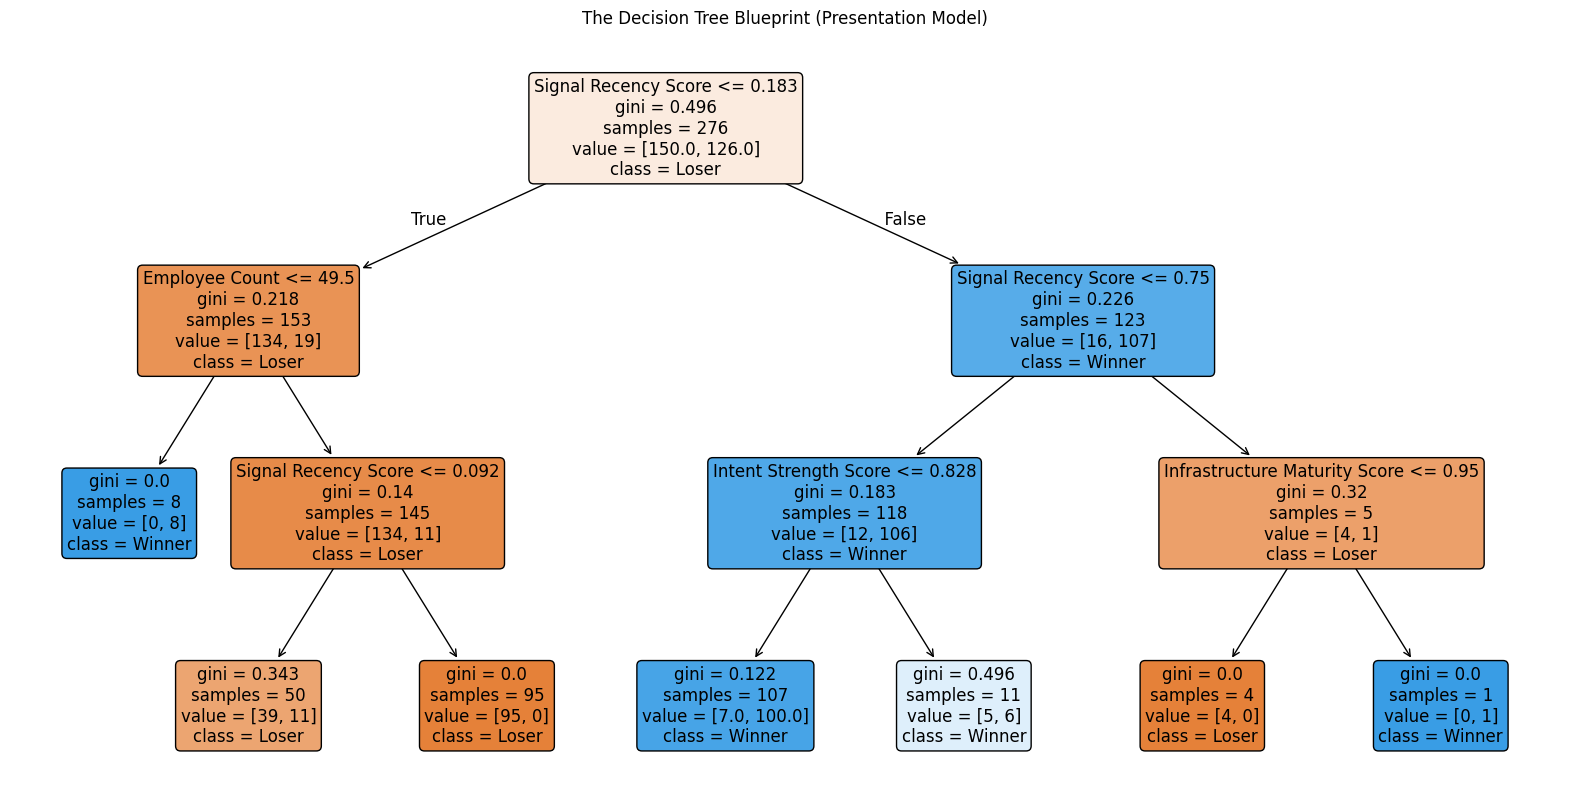

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X = df_combined[existing_features].copy()
y = df_combined['target']

X = X.fillna(0)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

print("Model trained successfully.")

plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=[f.split(' [')[0] for f in existing_features],
          class_names=['Loser', 'Winner'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("The Decision Tree Blueprint (Presentation Model)")
plt.show()

In [6]:
importances = pd.DataFrame({
    'Feature': [f.split(' [')[0] for f in existing_features],
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Top Buying Signals (Feature Importance) ---")
display(importances)

--- Top Buying Signals (Feature Importance) ---


,Feature,Importance
5,Signal Recency Score,0.826476
1,Employee Count,0.127891
3,Intent Strength Score,0.029831
2,Infrastructure Maturity Score,0.015801
0,Revenue,0.000000
4,Hiring Velocity,0.000000
6,Total Signals,0.000000
7,Total Funding Raised,0.000000
8,News Mentions,0.000000


In [8]:
propensity_scores = clf.predict_proba(X)[:, 1]

output_df = model_df.copy()
output_df['Propensity_Score'] = (propensity_scores * 100).round(2)

name_col = 'Company Name [canonical_name]'
print("--- Sample Propensity Scoring Results ---")
display(output_df[[name_col, 'target', 'Propensity_Score']].sort_values(by='Propensity_Score', ascending=False).head(10))

output_df.to_csv('blueprint_scored_sample.csv', index=False)
print("\nPreliminary scored list saved to 'blueprint_scored_sample.csv'.")

--- Sample Propensity Scoring Results ---


,Company Name [canonical_name],target,Propensity_Score
114,"Komax Corporation, Brookfield",1,100.00
61,US- Other Executive Office Agencies,1,100.00
65,US-Department of the Airforce,1,100.00
51,Federation Des Caisses,1,100.00
0,"beBOLD Digital - Full-Service Amazon, Walmart ...",1,100.00
106,Broadcasting News Corporation,1,100.00
14,Public Spend of Quebec,1,100.00
12,National Renewable Energy Laboratory [Nrel],1,100.00
108,The Walt Disney Company,1,100.00
29,Discover,1,93.46



Preliminary scored list saved to 'blueprint_scored_sample.csv'.


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf_clf.fit(X, y)

print("Random Forest Production Engine trained successfully.")

rf_importances = pd.DataFrame({
    'Feature': [f.split(' [')[0] for f in existing_features],
    'Importance': rf_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Production Engine: Top Buying Signals ---")
display(rf_importances)

Random Forest Production Engine trained successfully.

--- Production Engine: Top Buying Signals ---


,Feature,Importance
5,Signal Recency Score,0.443302
0,Revenue,0.203704
6,Total Signals,0.132440
1,Employee Count,0.118127
2,Infrastructure Maturity Score,0.044845
3,Intent Strength Score,0.037954
8,News Mentions,0.010838
7,Total Funding Raised,0.008790
4,Hiring Velocity,0.000000


In [10]:
production_scores = rf_clf.predict_proba(X)[:, 1]

output_df['RF_Propensity_Score'] = (production_scores * 100).round(2)

print("--- Comparison: Decision Tree vs. Random Forest Scores ---")
display(output_df[[name_col, 'Propensity_Score', 'RF_Propensity_Score']].sort_values(by='RF_Propensity_Score', ascending=False).head(10))

--- Comparison: Decision Tree vs. Random Forest Scores ---


,Company Name [canonical_name],Propensity_Score,RF_Propensity_Score
122,Kroger Pharmacy,93.46,99.03
117,Costco Wholesale,93.46,99.02
112,Kaiser Permanente,93.46,98.81
64,U.S. Department of Justice,93.46,98.74
22,American Express,93.46,98.73
26,Capital One,93.46,98.73
18,U.S. Department of Agriculture,93.46,98.65
90,John Deere,93.46,98.63
34,Morgan Stanley,93.46,98.58
47,TD,93.46,98.51


/tmp/ipykernel_4867/1181300966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importances, palette='viridis')


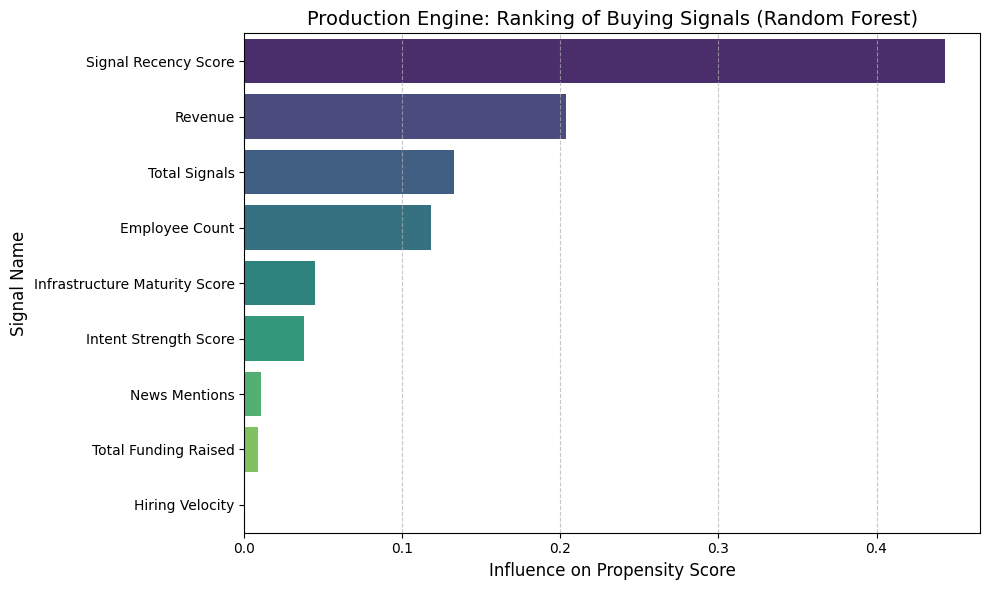

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances, palette='viridis')
plt.title('Production Engine: Ranking of Buying Signals (Random Forest)', fontsize=14)
plt.xlabel('Influence on Propensity Score', fontsize=12)
plt.ylabel('Signal Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
import joblib
import os
import json

export_dir = '/content/model_export'
os.makedirs(export_dir, exist_ok=True)

model_filename = os.path.join(export_dir, 'rf_production_model.joblib')
joblib.dump(rf_clf, model_filename)

metadata = {
    'features_used': existing_features,
    'feature_mapping': feature_mapping,
    'model_type': 'RandomForestClassifier',
    'max_depth': 5,
    'n_estimators': 100
}

with open(os.path.join(export_dir, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Model and Metadata successfully exported to: {export_dir}")
print(f"Files created: {os.listdir(export_dir)}")

Model and Metadata successfully exported to: /content/model_export
Files created: ['rf_production_model.joblib', 'model_metadata.json']


In [13]:
import os
import json

export_path = '/content/model_export'
files = os.listdir(export_path)

print(f"--- Export Verification ---")
print(f"Directory: {export_path}")
print(f"Files: {files}")

with open(os.path.join(export_path, 'model_metadata.json'), 'r') as f:
    meta_content = json.load(f)

print("\n--- Production Metadata Content ---")
display(meta_content)

--- Export Verification ---
Directory: /content/model_export
Files: ['rf_production_model.joblib', 'model_metadata.json']

--- Production Metadata Content ---


{'features_used': ['Revenue [revenue]',
  'Employee Count [employee_count]',
  'Infrastructure Maturity Score [infrastructure_maturity]',
  'Intent Strength Score [intent_strength_score]',
  'Hiring Velocity [hiring_velocity]',
  'Signal Recency Score [signal_recency]',
  'Total Signals [signal_count_total]',
  'Total Funding Raised [total_funding_raised]',
  'News Mentions [news_mentions_count]'],
 'feature_mapping': {'Revenue': 'Revenue [revenue]',
  'Employee Count': 'Employee Count [employee_count]',
  'Infrastructure Maturity': 'Infrastructure Maturity Score [infrastructure_maturity]',
  'Intent Strength': 'Intent Strength Score [intent_strength_score]',
  'Hiring Velocity': 'Hiring Velocity [hiring_velocity]',
  'Signal Recency': 'Signal Recency Score [signal_recency]',
  'Total Signals': 'Total Signals [signal_count_total]',
  'Total Funding': 'Total Funding Raised [total_funding_raised]',
  'News Mentions': 'News Mentions [news_mentions_count]'},
 'model_type': 'RandomForestCla

In [14]:
import joblib
import pandas as pd

reloaded_model = joblib.load('/content/model_export/rf_production_model.joblib')

reloaded_importances = pd.DataFrame({
    'Feature': meta_content['features_used'],
    'Importance': reloaded_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Verification: Reloaded Model Feature Rankings ---")
display(reloaded_importances)

--- Verification: Reloaded Model Feature Rankings ---


,Feature,Importance
5,Signal Recency Score [signal_recency],0.443302
0,Revenue [revenue],0.203704
6,Total Signals [signal_count_total],0.132440
1,Employee Count [employee_count],0.118127
2,Infrastructure Maturity Score [infrastructure_...,0.044845
3,Intent Strength Score [intent_strength_score],0.037954
8,News Mentions [news_mentions_count],0.010838
7,Total Funding Raised [total_funding_raised],0.008790
4,Hiring Velocity [hiring_velocity],0.000000
